<a href="https://colab.research.google.com/github/Renukadevi-03/CryptoCast-Multi-Horizon-Bitcoin-Price-Forecasting-Using-Deep-Learning/blob/main/CryptoCast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Title:
CryptoCast - Multi-Horizon Bitcoin Price Forecasting Using Deep Learning


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

In [21]:
df = pd.read_csv("Bitcoin Historical Data.csv")

In [22]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4999 non-null   object
 1   Price     4999 non-null   object
 2   Open      4999 non-null   object
 3   High      4999 non-null   object
 4   Low       4999 non-null   object
 5   Vol.      4993 non-null   object
 6   Change %  4999 non-null   object
dtypes: object(7)
memory usage: 273.5+ KB


In [24]:
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,6
Change %,0


Convert Date Correctly

In [25]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d-%m-%Y'
)

Sort Data

In [26]:
df = df.sort_values('Date')
df = df.reset_index(drop=True)

In [27]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
1,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
2,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
3,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%


Clean Price Columns

In [28]:
price_cols = ['Price','Open','High','Low']

for col in price_cols:
    df[col] = (
        df[col]
        .str.replace(',', '')
        .astype(float)
    )

Clean Change %

In [29]:
df['Change %'] = (
    df['Change %']
    .str.replace('%','')
    .astype(float)
)

Clean Volume Column

In [30]:
def convert_volume(vol):

    if pd.isna(vol):
        return np.nan

    vol = str(vol)

    if 'K' in vol:
        return float(vol.replace('K','')) * 1000

    elif 'M' in vol:
        return float(vol.replace('M','')) * 1000000

    elif 'B' in vol:
        return float(vol.replace('B','')) * 1000000000

    else:
        return float(vol)

In [31]:
df['Vol.'] = df['Vol.'].apply(convert_volume)

Handle Missing Volumes


In [32]:
df['Vol.'].isnull().sum()

np.int64(6)

In [33]:
# Why median - Because volume can have huge spikes so chose median
df['Vol.'] = df['Vol.'].fillna(
    df['Vol.'].median()
)

Verify Data Types

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[ns]
 1   Price     4999 non-null   float64       
 2   Open      4999 non-null   float64       
 3   High      4999 non-null   float64       
 4   Low       4999 non-null   float64       
 5   Vol.      4999 non-null   float64       
 6   Change %  4999 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 273.5 KB


EDA - Price Trend

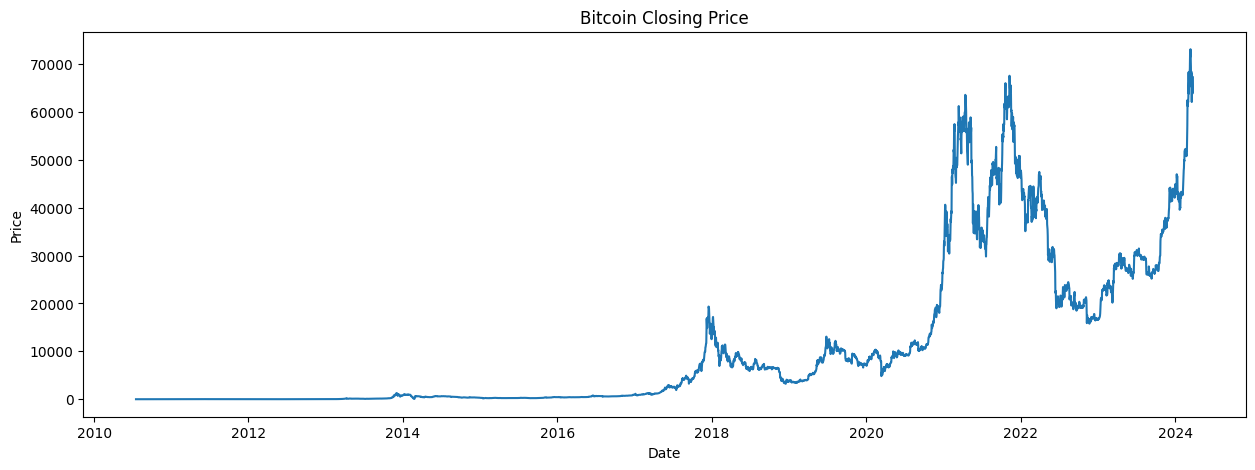

In [35]:
plt.figure(figsize=(15,5))

plt.plot(df['Date'],df['Price'])

plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

Distribution

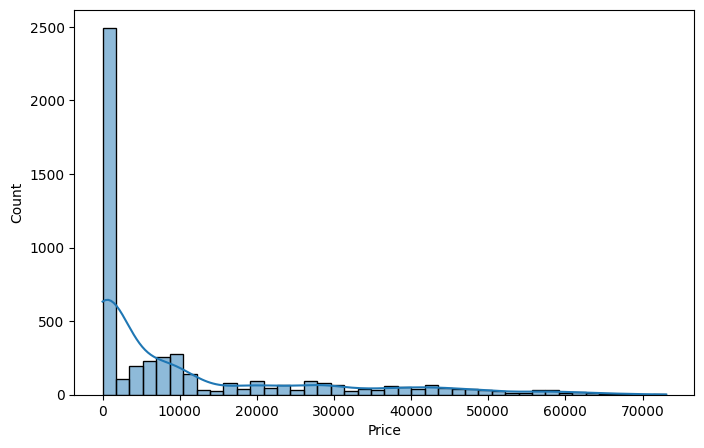

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Price'],
    kde=True
)

plt.show()

Correlation Heatmap

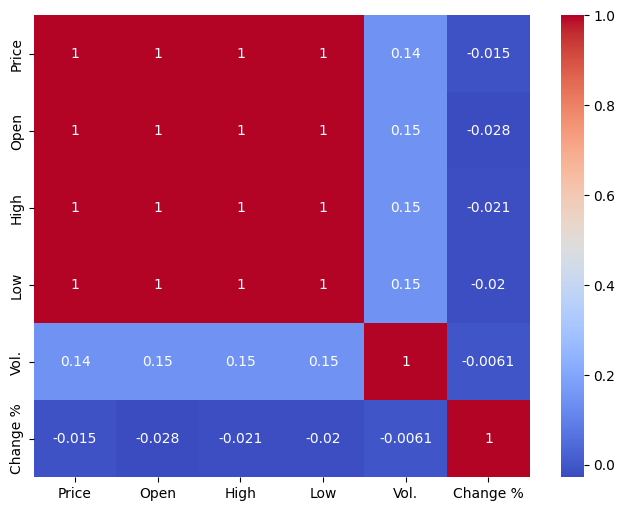

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop('Date',axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Feature Selection

In [38]:
features = [
    'Price',
    'Open',
    'High',
    'Low',
    'Vol.',
    'Change %'
]

Scaling

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[features]
)

In [40]:
scaled_data.shape

(4999, 6)

Create 60-Day Sequences

In [41]:
def create_sequences(data, window=60):

    X = []
    y = []

    for i in range(window, len(data)):

        X.append(
            data[i-window:i]
        )

        y.append(
            data[i,0]
        )

    return np.array(X), np.array(y)

In [42]:
X,y = create_sequences(
    scaled_data,
    window=60
)

In [43]:
print(X.shape)
print(y.shape)

(4939, 60, 6)
(4939,)


Train-Test Split

In [44]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [45]:
print(X_train.shape)
print(X_test.shape)

(3951, 60, 6)
(988, 60, 6)


In [48]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[ns]
 1   Price     4999 non-null   float64       
 2   Open      4999 non-null   float64       
 3   High      4999 non-null   float64       
 4   Low       4999 non-null   float64       
 5   Vol.      4999 non-null   float64       
 6   Change %  4999 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 273.5 KB


In [49]:
X.shape

(4939, 60, 6)

Create CNN Model

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense

cnn_model = Sequential()

cnn_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(60,6)
    )
)

cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Flatten())

cnn_model.add(Dense(50, activation='relu'))

cnn_model.add(Dense(1))

cnn_model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,117 (367.64 KB)

 Trainable params: 94,117 (367.64 KB)

 Non-trainable params: 0 (0.00 B)

Train CNN

In [58]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.6143e-04 - val_loss: 0.0053
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.5247e-05 - val_loss: 0.0034
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.6582e-05 - val_loss: 0.0043
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.2092e-05 - val_loss: 0.0024
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7521e-05 - val_loss: 0.0043
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.3431e-05 - val_loss: 0.0025
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0898e-05 - val_loss: 0.0034
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8098e-05 - val_loss: 0.0014
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.6476e-05 - val_loss: 0.0012
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2037e-05 - val_loss: 0.0020
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.8350e-05 - val_loss: 0.0021
Epoch 

In [60]:
cnn_pred = cnn_model.predict(X_test)
cnn_pred.shape

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


(988, 1)

Build RNN

In [61]:
from tensorflow.keras.layers import SimpleRNN

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        64,
        input_shape=(60,6)
    )
)

rnn_model.add(Dense(32, activation='relu'))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,657 (26.00 KB)

 Trainable params: 6,657 (26.00 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Train
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 6.0051e-04 - val_loss: 0.0214
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.2171e-05 - val_loss: 0.0177
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.4643e-05 - val_loss: 0.0173
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 5.4713e-05 - val_loss: 0.0156
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.0682e-05 - val_loss: 0.0160
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.4825e-05 - val_loss: 0.0134
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7974e-05 - val_loss: 0.0122
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.5454e-05 - val_loss: 0.0108
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.0534e-05 - val_loss: 0.0118
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.4713e-05 - val_loss: 0.0092
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3968e-05 - val_loss: 0.00

Create LSTM Model

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        units=64,
        input_shape=(60, 6)
    )
)

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [53]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 4.3315e-04 - val_loss: 0.0050
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 7.2872e-05 - val_loss: 0.0029
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 5.3923e-05 - val_loss: 0.0028
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 5.2185e-05 - val_loss: 0.0028
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 5.0898e-05 - val_loss: 0.0018
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 4.2181e-05 - val_loss: 0.0031
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.7999e-05 - val_loss: 0.0042
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.4170e-05 - val_loss: 0.0030
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.4013e-05 - val_loss: 0.0020
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 3.1252e-05 - val_loss: 0.0039
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 3.2457e-05 - val_loss: 0.00

Transformer Model

In [70]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling1D,
    MultiHeadAttention,
    LayerNormalization,
    Dropout
)

from tensorflow.keras.models import Model

inputs = Input(shape=(60,6))

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(
    inputs,
    inputs
)

x = LayerNormalization()(attention + inputs)

x = Dense(64, activation='relu')(x)

x = Dropout(0.2)(x)

x = GlobalAveragePooling1D()(x)

outputs = Dense(1)(x)

transformer_model = Model(
    inputs,
    outputs
)

transformer_model.compile(
    optimizer='adam',
    loss='mse'
)

transformer_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 6)     │      3,462 │ input_layer_3[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 6)     │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 6)     │         12 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 60, 64)    │        448 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 64)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_2[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,987 (15.57 KB)

 Trainable params: 3,987 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
transformer_history = transformer_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0025 - val_loss: 0.0872
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 7.6363e-04 - val_loss: 0.0875
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 5.6209e-04 - val_loss: 0.0847
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 4.5432e-04 - val_loss: 0.0916
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 3.9586e-04 - val_loss: 0.0926
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 3.1952e-04 - val_loss: 0.0871
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 2.6646e-04 - val_loss: 0.0874
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 2.4550e-04 - val_loss: 0.0946
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 2.4275e-04 - val_loss: 0.0916
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 2.2504e-04 - val_loss: 0.0955
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 1.9704e-04 - val_loss: 0.0892
E

Plot Training Curve

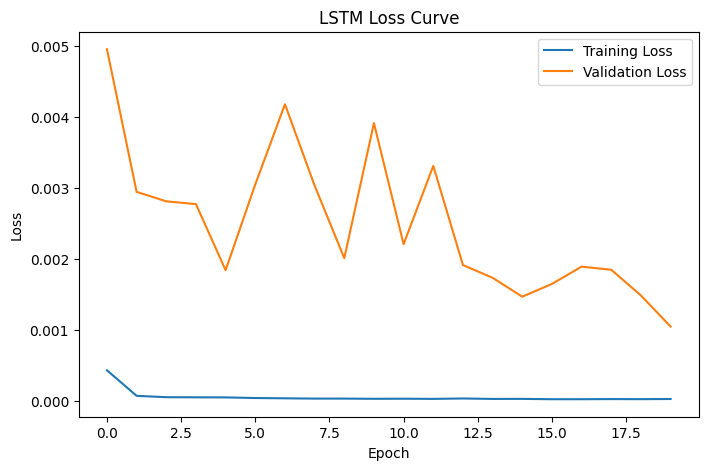

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [55]:
print(X_train.shape)
print(X_test.shape)

model.summary()

(3951, 60, 6)
(988, 60, 6)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,869 (237.77 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,580 (158.52 KB)

Create One Evaluation Function

In [63]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(model, X_test, y_test, scaler):

    pred = model.predict(X_test, verbose=0)

    # Predicted prices
    dummy_pred = np.zeros((len(pred), 6))
    dummy_pred[:, 0] = pred.flatten()

    pred_price = scaler.inverse_transform(
        dummy_pred
    )[:, 0]

    # Actual prices
    dummy_actual = np.zeros((len(y_test), 6))
    dummy_actual[:, 0] = y_test

    actual_price = scaler.inverse_transform(
        dummy_actual
    )[:, 0]

    mae = mean_absolute_error(
        actual_price,
        pred_price
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_price,
            pred_price
        )
    )

    mape = np.mean(
        np.abs(
            (actual_price - pred_price)
            / actual_price
        )
    ) * 100

    return mae, rmse, mape

In [64]:
# CNN
cnn_mae, cnn_rmse, cnn_mape = evaluate_model(
    cnn_model,
    X_test,
    y_test,
    scaler
)

In [65]:
# RNN
rnn_mae, rnn_rmse, rnn_mape = evaluate_model(
    rnn_model,
    X_test,
    y_test,
    scaler
)

In [67]:
# LSTM
lstm_mae, lstm_rmse, lstm_mape = evaluate_model(
    model,
    X_test,
    y_test,
    scaler
)

In [72]:
# Transformer
trans_mae, trans_rmse, trans_mape = evaluate_model(
    transformer_model,
    X_test,
    y_test,
    scaler
)

In [73]:
comparison = pd.DataFrame({

    'Model' : [
        'CNN',
        'RNN',
        'LSTM',
        'Transformer'
    ],

    'MAE' : [
        cnn_mae,
        rnn_mae,
        lstm_mae,
        trans_mae
    ],

    'RMSE' : [
        cnn_rmse,
        rnn_rmse,
        lstm_rmse,
        trans_rmse
    ],

    'MAPE' : [
        cnn_mape,
        rnn_mape,
        lstm_mape,
        trans_mape
    ]

})

comparison

,Model,MAE,RMSE,MAPE
0,CNN,2452.123612,2944.273907,7.024017
1,RNN,5003.298434,7071.318371,11.739634
2,LSTM,2012.497986,2843.969108,5.446228
3,Transformer,19489.815415,22900.535944,51.721158


Get LSTM Predictions

In [74]:
pred = model.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


Convert Scaled Values Back to Real Bitcoin Prices

In [75]:
import numpy as np

dummy_pred = np.zeros((len(pred), 6))
dummy_pred[:, 0] = pred.flatten()

pred_price = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_actual = np.zeros((len(y_test), 6))
dummy_actual[:, 0] = y_test

actual_price = scaler.inverse_transform(dummy_actual)[:, 0]

Actual vs Predicted Graph

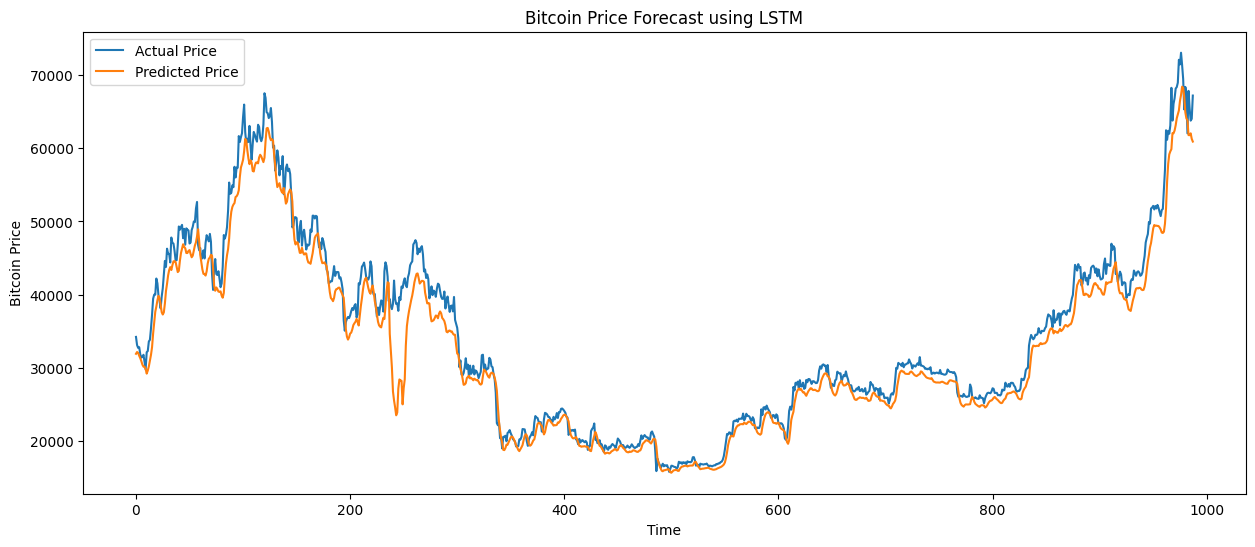

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(actual_price, label='Actual Price')
plt.plot(pred_price, label='Predicted Price')

plt.title('Bitcoin Price Forecast using LSTM')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price')
plt.legend()

plt.show()

LSTM Loss Curve

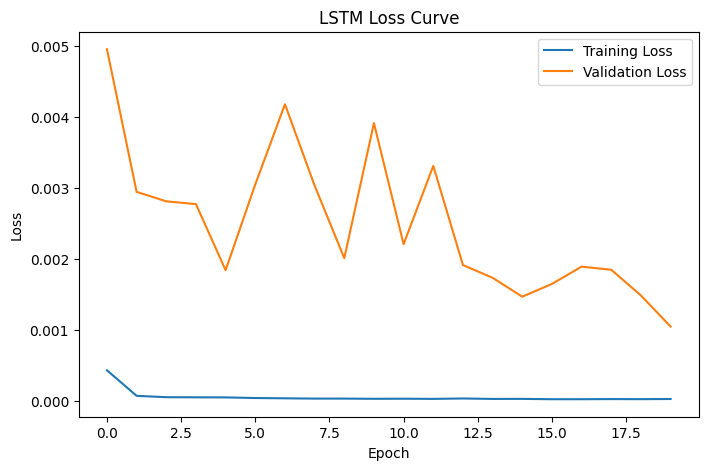

In [77]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('LSTM Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [78]:
print("Best Model : LSTM")
print("MAE :", lstm_mae)
print("RMSE :", lstm_rmse)
print("MAPE :", lstm_mape)

Best Model : LSTM
MAE : 2012.497985616166
RMSE : 2843.9691081036544
MAPE : 5.446227747538634


Create 3-Day Sequences

In [79]:
def create_sequences_3day(data, window=60):

    X = []
    y = []

    for i in range(window, len(data)-3):

        X.append(data[i-window:i])

        y.append(data[i:i+3, 0])

    return np.array(X), np.array(y)

In [80]:
X3, y3 = create_sequences_3day(scaled_data)

print(X3.shape)
print(y3.shape)

(4936, 60, 6)
(4936, 3)


Train/Test Split

In [81]:
split = int(len(X3) * 0.8)

X3_train = X3[:split]
X3_test = X3[split:]

y3_train = y3[:split]
y3_test = y3[split:]

Build 3-Day LSTM

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_3day = Sequential()

lstm_3day.add(
    LSTM(
        64,
        input_shape=(60,6)
    )
)

lstm_3day.add(Dropout(0.2))

lstm_3day.add(Dense(32, activation='relu'))

lstm_3day.add(Dense(3))

lstm_3day.compile(
    optimizer='adam',
    loss='mse'
)

lstm_3day.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,355 (79.51 KB)

 Trainable params: 20,355 (79.51 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# Train

history_3day = lstm_3day.fit(
    X3_train,
    y3_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1.8879e-04 - val_loss: 0.0050
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 6.6203e-05 - val_loss: 0.0027
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 5.8466e-05 - val_loss: 0.0029
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 5.4354e-05 - val_loss: 0.0034
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 4.9088e-05 - val_loss: 0.0036
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 4.7256e-05 - val_loss: 0.0032
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 4.2252e-05 - val_loss: 0.0044
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 4.0844e-05 - val_loss: 0.0032
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 3.9443e-05 - val_loss: 0.0044
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 4.0368e-05 - val_loss: 0.0033
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 3.7477e-05 - val_loss: 0.00

Evaluate 3-Day Model

In [84]:
pred3 = lstm_3day.predict(X3_test)

print(pred3.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
(988, 3)


In [94]:
pred3 = lstm_3day.predict(X3_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_3day = mean_absolute_error(
    y3_test.flatten(),
    pred3.flatten()
)

rmse_3day = np.sqrt(
    mean_squared_error(
        y3_test.flatten(),
        pred3.flatten()
    )
)

mape_3day = np.mean(
    np.abs(
        (y3_test.flatten() - pred3.flatten())
        / y3_test.flatten()
    )
) * 100

print("3-Day MAE :", mae_3day)
print("3-Day RMSE :", rmse_3day)
print("3-Day MAPE :", mape_3day)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
3-Day MAE : 0.04781546577965688
3-Day RMSE : 0.06291363599838917
3-Day MAPE : 9.422640837082657


7-Day Forecast

In [85]:
def create_sequences_7day(data, window=60):

    X = []
    y = []

    for i in range(window, len(data)-7):

        X.append(data[i-window:i])

        y.append(data[i:i+7, 0])

    return np.array(X), np.array(y)

In [86]:
X7, y7 = create_sequences_7day(scaled_data)

print(X7.shape)
print(y7.shape)

(4932, 60, 6)
(4932, 7)


In [87]:
# Train-Test Split

split = int(len(X7) * 0.8)

X7_train = X7[:split]
X7_test = X7[split:]

y7_train = y7[:split]
y7_test = y7[split:]

In [88]:
print(X7_train.shape)
print(X7_test.shape)

(3945, 60, 6)
(987, 60, 6)


Build LSTM Model

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

lstm_7day = Sequential()

lstm_7day.add(
    LSTM(
        64,
        input_shape=(60,6)
    )
)

lstm_7day.add(
    Dropout(0.2)
)

lstm_7day.add(
    Dense(
        32,
        activation='relu'
    )
)

lstm_7day.add(
    Dense(7)
)

lstm_7day.compile(
    optimizer='adam',
    loss='mse'
)

lstm_7day.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,487 (80.03 KB)

 Trainable params: 20,487 (80.03 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# Train Model

history_7day = lstm_7day.fit(
    X7_train,
    y7_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 4.2726e-04 - val_loss: 0.0088
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 1.0788e-04 - val_loss: 0.0107
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 8.9744e-05 - val_loss: 0.0099
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 8.0350e-05 - val_loss: 0.0074
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 7.4160e-05 - val_loss: 0.0063
Epoch 6/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 6.9751e-05 - val_loss: 0.0068
Epoch 7/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 6.2565e-05 - val_loss: 0.0073
Epoch 8/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 6.1307e-05 - val_loss: 0.0072
Epoch 9/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 6.0919e-05 - val_loss: 0.0057
Epoch 10/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 5.8354e-05 - val_loss: 0.0063
Epoch 11/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 5.9466e-05 - val_loss: 0.00

In [91]:
# Predict

pred7 = lstm_7day.predict(X7_test)

print(pred7.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
(987, 7)


In [92]:
# Evaluate

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae_7day = mean_absolute_error(
    y7_test.flatten(),
    pred7.flatten()
)

rmse_7day = np.sqrt(
    mean_squared_error(
        y7_test.flatten(),
        pred7.flatten()
    )
)

mape_7day = np.mean(
    np.abs(
        (y7_test.flatten() -
         pred7.flatten())
        /
        y7_test.flatten()
    )
) * 100

print("7-Day MAE :", mae_7day)
print("7-Day RMSE :", rmse_7day)
print("7-Day MAPE :", mape_7day)

7-Day MAE : 0.07228177384953882
7-Day RMSE : 0.0907426491563018
7-Day MAPE : 14.36875764856141


Horizon Comparison Table

In [95]:
horizon_comparison = pd.DataFrame({

    "Forecast Horizon": [
        "1-Day",
        "3-Day",
        "7-Day"
    ],

    "MAE": [
        lstm_mae,
        mae_3day,
        mae_7day
    ],

    "RMSE": [
        lstm_rmse,
        rmse_3day,
        rmse_7day
    ],

    "MAPE": [
        lstm_mape,
        mape_3day,
        mape_7day
    ]
})

horizon_comparison

,Forecast Horizon,MAE,RMSE,MAPE
0,1-Day,2012.497986,2843.969108,5.446228
1,3-Day,0.047815,0.062914,9.422641
2,7-Day,0.072282,0.090743,14.368758
